# Notebook 02 — Calidad, limpieza y preparación

## Planteamiento de trabajo

En esta etapa transformamos el dataset crudo en una versión lista para analizar. La regla central del trabajo es clara: **ninguna decisión de limpieza sin evidencia**. Por eso, para cada cambio mostramos primero qué observamos, luego la acción aplicada y finalmente su impacto en el dataset.

Trabajamos sobre una **copia** (el original queda intacto en `data/raw/`), guardamos el resultado en `data/processed/` y registramos cada transformación en `logs/pipeline_log.csv` para dejar trazabilidad completa.

**Problemas detectados en la inspección inicial que vamos a resolver:** registros duplicados, categorías escritas de distintas formas, fechas con varios formatos, y valores imposibles o faltantes en las variables numéricas.

## 1. Carga y preparación inicial

### Librerías

In [57]:
import pandas as pd
import numpy as np

Se importan pandas y numpy, las librerías base para manipular y analizar los datos.

### Carga del dataset

In [58]:
df = pd.read_json("../data/raw/streaming_users_dirty.json")

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


Se carga el dataset original desde `data/raw/`. El archivo original no se modifica en ningún momento.

### Vista previa

In [59]:
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crime,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


La vista previa confirma la estructura esperada: una fila por usuario con sus 8 variables.

### Copia de trabajo

In [60]:
# Crear copia de trabajo

df_limpio = df.copy()

print("Copia de trabajo creada correctamente.")

Copia de trabajo creada correctamente.


Todas las transformaciones se hacen sobre `df_limpio`, una copia. Así el original queda intacto.

### Estado inicial del dataset

In [61]:
# Estado inicial del dataset

estado_inicial = pd.DataFrame({
    "Filas": [df_limpio.shape[0]],
    "Columnas": [df_limpio.shape[1]],
    "Valores faltantes": [df_limpio.isnull().sum().sum()],
    "Duplicados": [df_limpio.duplicated().sum()]
})

estado_inicial

,Filas,Columnas,Valores faltantes,Duplicados
0,8160,8,753,126


Punto de partida para medir el impacto de la limpieza: 8160 filas, 753 faltantes y 126 duplicados.

## 2. Tratamiento de registros duplicados

Eliminamos solo los registros **completamente** duplicados. Los `user_id` repetidos que difieren en alguna columna se conservan, porque no son copias exactas.

### Conteo de duplicados completos

In [62]:
# Registros completamente duplicados

duplicados = df_limpio.duplicated().sum()

print(f"Registros completamente duplicados: {duplicados}")


Registros completamente duplicados: 126


Se confirman 126 filas idénticas en todas sus columnas.

### Eliminación de duplicados

In [63]:
# Eliminación de registros duplicados


filas_antes = df_limpio.shape[0]

df_limpio = df_limpio.drop_duplicates()

filas_despues = df_limpio.shape[0]

print(f"Filas antes : {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Registros eliminados: {filas_antes - filas_despues}")

Filas antes : 8160
Filas después: 8034
Registros eliminados: 126


El dataset pasa de 8160 a 8034 filas (se quitan 126), sin perder información única.

### Verificación

In [64]:
# Verificación posterior
duplicados_restantes = df_limpio.duplicated().sum()

print(f"Duplicados restantes: {duplicados_restantes}")

Duplicados restantes: 0


Ya no quedan registros completamente duplicados.

## 3. Estandarización de variables categóricas

Una misma categoría aparece escrita de varias formas (mayúsculas, tildes, abreviaturas, traducciones). Las unificamos para que cada una tenga una sola representación.

### Limpieza de espacios

In [65]:
columnas_categoricas = [
    "subscription_plan",
    "country",
    "favorite_genre"
]

for columna in columnas_categoricas:
    df_limpio[columna] = df_limpio[columna].str.strip()

Se quitan los espacios invisibles al inicio y final de los textos, paso previo a la estandarización.

### Estandarización de `subscription_plan`

In [66]:
# Estandarización de subscription_plan

planes = {
    "basico": "Básico",
    "básico": "Básico",
    "BASICO": "Básico",
    "Basic": "Básico",

    "Std": "Estándar",
    "estandar": "Estándar",
    "STANDARD": "Estándar",

    "premium": "Premium",
    "PREMIUM": "Premium",
    "Premiun": "Premium"
}

df_limpio["subscription_plan"] = (
    df_limpio["subscription_plan"]
    .replace(planes)
)

Se aplican las equivalencias para unir las variantes de escritura en los 3 planes reales.

### Resultado en `subscription_plan`

In [67]:
df_limpio["subscription_plan"].value_counts()

subscription_plan
Básico      3609
Estándar    2833
Premium     1592
Name: count, dtype: int64

Las variantes quedaron consolidadas en las tres categorías oficiales: Básico, Estándar y Premium.

### Estandarización de `country`

In [68]:
paises = {
    "Brazil": "Brasil",
    "BRA": "Brasil",
    "brasil": "Brasil",

    "Argentina": "Argentina",
    "argentina": "Argentina",
    "ARG": "Argentina",

    "Chile": "Chile",
    "chile": "Chile",
    "CHL": "Chile",

    "Colombia": "Colombia",
    "colombia": "Colombia",
    "COL": "Colombia",

    "Mexico": "México",
    "méxico": "México",
    "MEX": "México",

    "Peru": "Perú",
    "perú": "Perú",
    "PER": "Perú",

    "uruguay": "Uruguay",
    "URY": "Uruguay"
}

df_limpio["country"] = df_limpio["country"].replace(paises)

df_limpio["country"].value_counts()

country
Chile        1167
Brasil       1164
México       1162
Uruguay      1146
Colombia     1145
Perú         1139
Argentina    1111
Name: count, dtype: int64

Las 26 variantes (traducciones, abreviaturas, mayúsculas) quedaron reducidas a los 7 países reales.

### Estandarización de `favorite_genre`

In [69]:
generos = {
    # Acción
    "Action": "Acción",
    "accion": "Acción",
    "ACCIÓN": "Acción",

    # Comedia
    "COMEDIA": "Comedia",
    "comedy": "Comedia",

    # Drama
    "DRAMA": "Drama",
    "drama": "Drama",

    # Romance
    "ROMANCE": "Romance",
    "romance": "Romance",

    # Thriller
    "THRILLER": "Thriller",
    "thriler": "Thriller",

    # Crime
    "CRIME": "Crime",
    "crime": "Crime",
    "Crimen": "Crime",

    # Documental
    "Documentary": "Documental",
    "DOC": "Documental",
    "documental": "Documental"
}

df_limpio["favorite_genre"] = df_limpio["favorite_genre"].replace(generos)

df_limpio["favorite_genre"].value_counts(dropna=False)

favorite_genre
Comedia       1141
Drama         1121
Romance       1113
Documental    1111
Acción        1110
Thriller      1109
Crime         1089
NaN            240
Name: count, dtype: int64

Los 28 valores se consolidaron en 7 géneros. Los faltantes se conservan para tratarlos más adelante.

## 4. Tratamiento de la fecha de último ingreso

La variable viene como texto, con formatos mezclados y valores inválidos. La convertimos a fecha real con cuidado de no inventar datos.

### Tipo actual de la variable

In [70]:
# Tipo actual de la variable fecha
print(df_limpio["last_login_date"].dtype)

str


La fecha está guardada como texto (object), no como fecha real.

### Ejemplo de un valor

In [71]:
print(df_limpio["last_login_date"].iloc[0])
print(type(df_limpio["last_login_date"].iloc[0]))

2025-03-04
<class 'str'>


Confirmamos que cada fecha es una cadena de texto.

### Formatos presentes

In [72]:
# Identificar los formatos presentes en last_login_date

# Valores distintos que no son nulos
fechas = df_limpio["last_login_date"].dropna()

# Clasificación por patrón
formato_iso = fechas.str.match(r"^\d{4}-\d{2}-\d{2}$").sum()
formato_guiones = fechas.str.match(r"^\d{2}-\d{2}-\d{4}$").sum()
formato_barras = fechas.str.match(r"^\d{4}/\d{2}/\d{2}$").sum()

print(f"Formato AAAA-MM-DD : {formato_iso}")
print(f"Formato ##-##-#### : {formato_guiones}")
print(f"Formato AAAA/MM/DD : {formato_barras}")

print("\nValores que no coinciden con ninguno de esos formatos:\n")

otros = fechas[
    ~(fechas.str.match(r"^\d{4}-\d{2}-\d{2}$") |
      fechas.str.match(r"^\d{2}-\d{2}-\d{4}$") |
      fechas.str.match(r"^\d{4}/\d{2}/\d{2}$"))
]

print(otros.value_counts().head(20))

Formato AAAA-MM-DD : 7302
Formato ##-##-#### : 265
Formato AAAA/MM/DD : 133

Valores que no coinciden con ninguno de esos formatos:

last_login_date
not_available    14
Name: count, dtype: int64


Conviven tres formatos válidos de fecha y un valor textual ('not_available').

### Formato ambiguo: primer número

In [73]:
# Analizar el formato ##-##-####


fechas_guiones = df_limpio[
    df_limpio["last_login_date"]
    .str.match(r"^\d{2}-\d{2}-\d{4}$", na=False)
]["last_login_date"]

# Primer número (antes del primer guion)
primer_numero = fechas_guiones.str[:2].astype(int)

print("Empiezan con un número mayor a 12:")
print((primer_numero > 12).sum())

print("\nEmpiezan con un número menor o igual a 12:")
print((primer_numero <= 12).sum())

Empiezan con un número mayor a 12:
85

Empiezan con un número menor o igual a 12:
180


85 fechas empiezan con un número mayor a 12, que solo puede ser el día.

### Formato ambiguo: segundo número

In [74]:
# Analizar el segundo número en las fechas ##-##-####

segundo_numero = fechas_guiones.str[3:5].astype(int)

print("Segundo número mayor a 12:")
print((segundo_numero > 12).sum())

print("\nSegundo número menor o igual a 12:")
print((segundo_numero <= 12).sum())

Segundo número mayor a 12:
78

Segundo número menor o igual a 12:
187


78 fechas tienen el segundo número mayor a 12 (el mes); el resto queda ambiguo.

### Conversión a fecha

In [75]:
# Conversión robusta de last_login_date

# Crear la nueva columna
df_limpio["last_login_date_limpia"] = pd.NaT

# -------- 1. Formato AAAA-MM-DD --------

mascara_iso = df_limpio["last_login_date"].str.match(
    r"^\d{4}-\d{2}-\d{2}$",
    na=False
)

df_limpio.loc[mascara_iso, "last_login_date_limpia"] = pd.to_datetime(
    df_limpio.loc[mascara_iso, "last_login_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

# -------- 2. Formato AAAA/MM/DD --------

mascara_barras = df_limpio["last_login_date"].str.match(
    r"^\d{4}/\d{2}/\d{2}$",
    na=False
)

df_limpio.loc[mascara_barras, "last_login_date_limpia"] = pd.to_datetime(
    df_limpio.loc[mascara_barras, "last_login_date"],
    format="%Y/%m/%d",
    errors="coerce"
)

# -------- 3. Fechas con ##-##-#### --------

mascara_doble = df_limpio["last_login_date"].str.match(
    r"^\d{2}-\d{2}-\d{4}$",
    na=False
)

fechas_dobles = df_limpio.loc[mascara_doble, "last_login_date"]

primer_numero = fechas_dobles.str[:2].astype(int)
segundo_numero = fechas_dobles.str[3:5].astype(int)

# DD-MM-AAAA (primer número > 12)
mascara_ddmm = primer_numero > 12

df_limpio.loc[
    fechas_dobles.index[mascara_ddmm],
    "last_login_date_limpia"
] = pd.to_datetime(
    fechas_dobles[mascara_ddmm],
    format="%d-%m-%Y",
    errors="coerce"
)

# MM-DD-AAAA (segundo número > 12)
mascara_mmdd = segundo_numero > 12

df_limpio.loc[
    fechas_dobles.index[mascara_mmdd],
    "last_login_date_limpia"
] = pd.to_datetime(
    fechas_dobles[mascara_mmdd],
    format="%m-%d-%Y",
    errors="coerce"
)


# Resumen de la conversión
print("Fechas convertidas correctamente:",
      df_limpio["last_login_date_limpia"].notna().sum())

print("Valores NaT:",
      df_limpio["last_login_date_limpia"].isna().sum())

Fechas convertidas correctamente: 7548
Valores NaT: 486


Se convierten las fechas interpretables sin riesgo; las ambiguas o imposibles quedan como NaT. Resultado: 7548 fechas válidas y 486 NaT.

### Reemplazo de la columna

In [76]:
# Reemplazar la columna original

df_limpio["last_login_date"] = df_limpio["last_login_date_limpia"]

df_limpio.drop(columns="last_login_date_limpia", inplace=True)

print(df_limpio["last_login_date"].dtype)

datetime64[ns]


La columna queda finalmente como tipo fecha (datetime).

### Dimensiones tras el tratamiento

In [77]:
print(f"Filas: {df_limpio.shape[0]}")
print(f"Columnas: {df_limpio.shape[1]}")

Filas: 8034
Columnas: 8


El dataset mantiene 8034 filas y 8 columnas.

## 5. Análisis de los valores faltantes

Antes de tratar los faltantes, los inspeccionamos para elegir la estrategia adecuada en cada variable.

### Faltantes por variable

In [78]:
# INSPECCIÓN DE VALORES FALTANTES

# Cantidad total de registros del dataset
total_filas = len(df_limpio)

# Cantidad de valores faltantes por columna
faltantes = df_limpio.isna().sum()

# Porcentaje de valores faltantes
porcentaje = (faltantes / total_filas) * 100

# Construimos una tabla resumen
resumen_faltantes = (
    pd.DataFrame({
        "Valores faltantes": faltantes,
        "Porcentaje (%)": porcentaje
    })
    .sort_values(by="Valores faltantes", ascending=False)
)

# Redondeamos el porcentaje para una mejor presentación
resumen_faltantes["Porcentaje (%)"] = resumen_faltantes["Porcentaje (%)"].round(2)

# Mostramos el resultado
resumen_faltantes

,Valores faltantes,Porcentaje (%)
last_login_date,486,6.05
favorite_genre,240,2.99
monthly_watch_time_mins,193,2.40
user_id,0,0.00
subscription_plan,0,0.00
age,0,0.00
country,0,0.00
customer_support_tickets,0,0.00


Solo tres variables tienen faltantes: fecha (6,05%), género (2,99%) y tiempo de visualización (2,40%). El resto está completo.

### Registros incompletos

In [79]:
# REGISTROS CON AL MENOS UN VALOR FALTANTE

# Crear un DataFrame con todos los registros que presentan
# al menos un valor faltante
df_faltantes = df_limpio[df_limpio.isna().any(axis=1)]

# Mostrar la cantidad de registros encontrados
print(f"Registros con al menos un valor faltante: {len(df_faltantes)}")

# Visualizar las primeras filas
df_faltantes.head()

Registros con al menos un valor faltante: 893


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
28,10028,22,Premium,NaN,Argentina,Documental,2023-01-14,0
30,10030,46,Básico,598.8,Argentina,NaN,2021-02-13,3
38,10038,59,Premium,NaN,Uruguay,Romance,2020-05-31,0
55,10055,41,Estándar,1180.4,Argentina,NaN,2021-04-15,2
64,10064,36,Estándar,592.5,Brasil,Thriller,NaT,2


Hay 893 registros con al menos un dato faltante.

### Faltantes por registro

In [80]:
# CANTIDAD DE VALORES FALTANTES POR REGISTRO

# Contar cuántos valores faltantes tiene cada fila
faltantes_por_fila = df_limpio.isna().sum(axis=1)

# Resumen de frecuencias
resumen_filas = (
    faltantes_por_fila
    .value_counts()
    .sort_index()
)

print("Cantidad de registros según el número de valores faltantes:\n")
print(resumen_filas)

Cantidad de registros según el número de valores faltantes:

0    7141
1     867
2      26
Name: count, dtype: int64


Casi el 89% de los registros está completo; los incompletos tienen, en general, un solo dato faltante.

### Patrones de faltantes

In [81]:
# PATRONES DE VALORES FALTANTES


# Seleccionar únicamente las columnas con valores faltantes
columnas_faltantes = [
    "last_login_date",
    "favorite_genre",
    "monthly_watch_time_mins"
]

# Obtener los patrones de valores faltantes
patrones_faltantes = (
    df_limpio[columnas_faltantes]
    .isna()
    .value_counts()
    .reset_index(name="Cantidad")
)

# Mostrar los patrones encontrados
patrones_faltantes

,last_login_date,favorite_genre,monthly_watch_time_mins,Cantidad
0,False,False,False,7141
1,True,False,False,465
2,False,True,False,226
3,False,False,True,176
4,True,False,True,12
5,True,True,False,9
6,False,True,True,5


Las ausencias aparecen de forma independiente, sin un patrón sistemático entre variables.

## 6. Tratamiento de `monthly_watch_time_mins`

Tenía valores imposibles y faltantes. Lo resolvemos en dos pasos: primero los valores inválidos, después los faltantes.

### Estadísticas iniciales

In [82]:
# ANÁLISIS DE monthly_watch_time_mins
# Estadísticas descriptivas

# Mostrar estadísticas descriptivas de la variable
df_limpio["monthly_watch_time_mins"].describe()

count     7841.000000
mean      1111.796965
std       5352.601506
min       -120.000000
25%        488.000000
50%        757.200000
75%       1044.400000
max      99999.000000
Name: monthly_watch_time_mins, dtype: float64

El resumen revela valores imposibles (negativos y hasta 99999) que distorsionan la variable.

### Distribución (histograma)

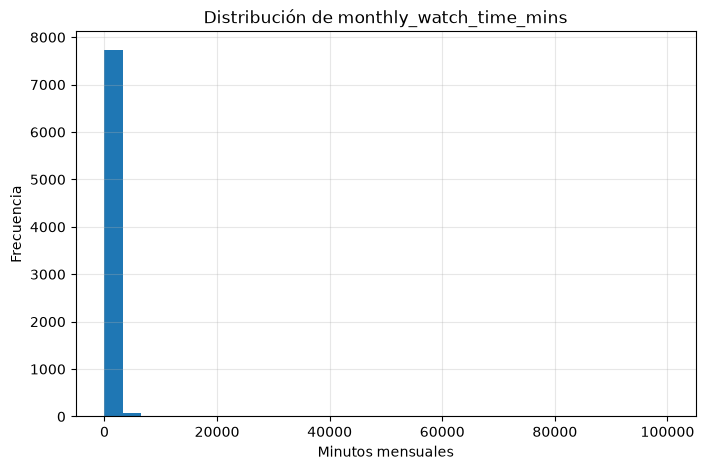

In [83]:
# HISTOGRAMA

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_limpio["monthly_watch_time_mins"].dropna(),
    bins=30
)

plt.title("Distribución de monthly_watch_time_mins")
plt.xlabel("Minutos mensuales")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)

plt.show()

El histograma muestra que unos pocos valores extremos deforman toda la distribución.

### Valores atípicos (boxplot)

C:\Users\mateo\AppData\Local\Temp\ipykernel_20688\1268503197.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


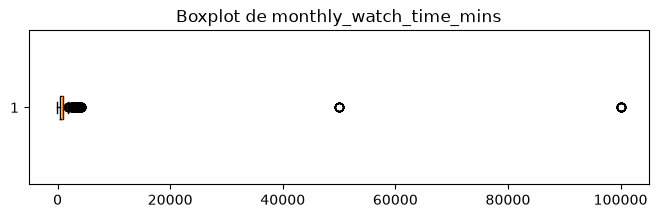

In [84]:
# BOXPLOT

plt.figure(figsize=(8,2))

plt.boxplot(
    df_limpio["monthly_watch_time_mins"].dropna(),
    vert=False
)

plt.title("Boxplot de monthly_watch_time_mins")

plt.show()

El boxplot confirma la presencia de valores muy alejados del resto.

### Identificación de valores imposibles

In [85]:
# INSPECCIÓN DE VALORES ATÍPICOS EVIDENTES

# Máximo de minutos posibles en un mes de 30 días
max_minutos_mes = 30 * 24 * 60  # 43200 minutos

# Filtrar registros con valores imposibles
outliers_evidentes = df_limpio[
    (df_limpio["monthly_watch_time_mins"] < 0) |
    (df_limpio["monthly_watch_time_mins"] > max_minutos_mes)
]

print(f"Cantidad de valores atípicos evidentes: {len(outliers_evidentes)}")

outliers_evidentes.sort_values(
    by="monthly_watch_time_mins",
    ascending=False
)

Cantidad de valores atípicos evidentes: 80


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
430,10430,16,Básico,99999.0,Argentina,Drama,NaT,3
588,10588,31,Básico,99999.0,Brasil,Documental,2020-03-26,1
1072,11072,22,Estándar,99999.0,Brasil,Drama,2018-05-31,2
1250,11250,49,Básico,99999.0,Brasil,Drama,2024-12-13,1
1304,11304,13,Básico,99999.0,Perú,Crime,2024-10-22,0
...,...,...,...,...,...,...,...,...
7014,17014,18,Básico,-120.0,Uruguay,Romance,2025-09-27,0
7018,17018,36,Básico,-120.0,Colombia,Romance,2025-03-31,1
7474,17474,44,Básico,-120.0,Chile,Documental,2024-12-18,0
7093,17093,18,Básico,-120.0,Argentina,Crime,2024-10-26,2


Se detectan 80 valores imposibles: tiempos negativos o superiores al máximo de minutos que tiene un mes.

### Frecuencia de los valores imposibles

In [86]:
# FRECUENCIA DE LOS VALORES ATÍPICOS
# Contar la frecuencia de cada valor atípico

frecuencia_outliers = (
    outliers_evidentes["monthly_watch_time_mins"]
    .value_counts()
    .sort_index()
)

print("Frecuencia de los valores atípicos:\n")
print(frecuencia_outliers)

Frecuencia de los valores atípicos:

monthly_watch_time_mins
-120.0      29
-1.0        20
 50000.0    11
 99999.0    20
Name: count, dtype: int64


Los valores problemáticos son -120, -1, 50000 y 99999.

### Impacto de convertirlos a NaN

In [87]:
# SIMULACIÓN DEL IMPACTO DE CONVERTIR VALORES INVÁLIDOS A NaN

# Crear una copia temporal de la variable
watch_time_simulada = df_limpio["monthly_watch_time_mins"].copy()

# Reemplazar únicamente en la copia
watch_time_simulada = watch_time_simulada.replace(
    [-120, -1, 50000, 99999],
    pd.NA
)

# Mostrar la cantidad de valores faltantes que tendría
print("Valores faltantes actuales:",
      df_limpio["monthly_watch_time_mins"].isna().sum())

print("Valores faltantes luego de convertir los valores inválidos:",
      watch_time_simulada.isna().sum())

Valores faltantes actuales: 193
Valores faltantes luego de convertir los valores inválidos: 273


Convertirlos a faltantes lleva los nulos de 193 a 273: un impacto acotado y preferible a mantener datos falsos.

### Conversión de inválidos a NaN

In [88]:
# CONVERSIÓN DE VALORES INVÁLIDOS A NaN
# Reemplazar los valores inválidos por NaN
df_limpio["monthly_watch_time_mins"] = df_limpio["monthly_watch_time_mins"].replace(
    [-120, -1, 50000, 99999],
    pd.NA
)

# Verificar la cantidad de valores faltantes
print("Valores faltantes actuales:")
print(df_limpio["monthly_watch_time_mins"].isna().sum())

Valores faltantes actuales:
273


Los valores imposibles pasan a faltantes para no distorsionar el análisis.

### Tipo de la variable

In [89]:
# VERIFICAR EL TIPO DE DATO DE LA VARIABLE
print(df_limpio["monthly_watch_time_mins"].dtype)

object


Tras la conversión la variable quedó como texto; hay que pasarla a numérica.

### Conversión a numérico

In [90]:
# CONVERTIR LA VARIABLE A TIPO NUMÉRICO
df_limpio["monthly_watch_time_mins"] = pd.to_numeric(
    df_limpio["monthly_watch_time_mins"],
    errors="coerce"
)

print(df_limpio["monthly_watch_time_mins"].dtype)

float64


La variable vuelve a ser numérica.

### Estadísticas tras la limpieza

In [91]:
# ESTADÍSTICAS DESCRIPTIVAS ACTUALIZADAS
df_limpio["monthly_watch_time_mins"].describe()

count    7761.000000
mean      795.144956
std       495.798957
min         0.000000
25%       491.800000
50%       758.500000
75%      1042.200000
max      4193.700000
Name: monthly_watch_time_mins, dtype: float64

Sin los valores imposibles, la variable queda en un rango realista (0 a ~4194 minutos).

### Distribución corregida

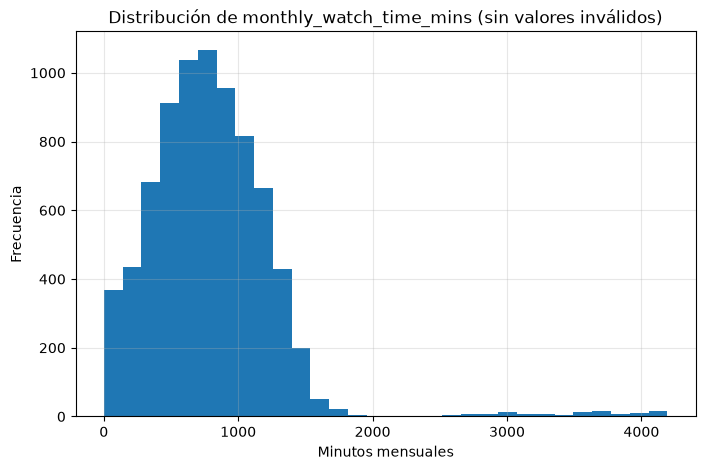

In [92]:
# HISTOGRAMA ACTUALIZADO

plt.figure(figsize=(8,5))

plt.hist(
    df_limpio["monthly_watch_time_mins"].dropna(),
    bins=30
)

plt.title("Distribución de monthly_watch_time_mins (sin valores inválidos)")
plt.xlabel("Minutos mensuales")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)

plt.show()

El histograma ahora refleja el comportamiento real de los usuarios.

### Boxplot corregido

C:\Users\mateo\AppData\Local\Temp\ipykernel_20688\1230504084.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


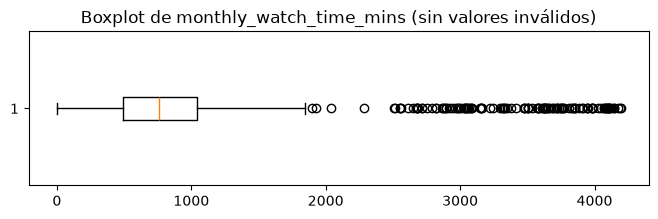

In [93]:
# BOXPLOT ACTUALIZADO
plt.figure(figsize=(8,2))

plt.boxplot(
    df_limpio["monthly_watch_time_mins"].dropna(),
    vert=False
)

plt.title("Boxplot de monthly_watch_time_mins (sin valores inválidos)")

plt.show()

La distribución queda mucho más razonable, sin los extremos artificiales.

### Tiempo según el plan

In [94]:
# ESTADÍSTICAS DE monthly_watch_time_mins
# SEGÚN EL PLAN DE SUSCRIPCIÓN


estadisticas_plan = (
    df_limpio
    .groupby("subscription_plan")["monthly_watch_time_mins"]
    .agg(
        Cantidad="count",
        Media="mean",
        Mediana="median",
        Desviacion="std",
        Minimo="min",
        Maximo="max"
    )
    .round(2)
)

estadisticas_plan

,Cantidad,Media,Mediana,Desviacion,Minimo,Maximo
subscription_plan,,,,,,
Básico,3570,597.55,552.45,461.05,0.0,4142.6
Estándar,2769,872.31,840.50,441.10,0.0,4193.7
Premium,1422,1140.96,1127.15,447.38,66.1,4188.7


El consumo difiere claramente entre planes (Premium > Estándar > Básico). Esto justifica imputar por grupo y no con un valor único.

### Imputación por mediana según el plan

In [95]:
# IMPUTACIÓN POR MEDIANA SEGÚN EL PLAN DE SUSCRIPCIÓN

# Reemplazar los valores faltantes utilizando la mediana
# correspondiente a cada plan de suscripción
df_limpio["monthly_watch_time_mins"] = (
    df_limpio
    .groupby("subscription_plan")["monthly_watch_time_mins"]
    .transform(lambda x: x.fillna(x.median()))
)

# Verificar que no queden valores faltantes
print("Valores faltantes restantes:")
print(df_limpio["monthly_watch_time_mins"].isna().sum())

Valores faltantes restantes:
0


Los faltantes se completan con la mediana de cada plan, preservando las diferencias entre grupos. Quedan 0 faltantes.

## 7. Tratamiento de `favorite_genre`

Revisamos cómo se reparten los géneros para decidir cómo completar los faltantes.

### Distribución de géneros

In [96]:
# DISTRIBUCIÓN DE favorite_genre

# Cantidad de registros por género
frecuencia_generos = (
    df_limpio["favorite_genre"]
    .value_counts(dropna=False)
)

# Porcentaje por género
porcentaje_generos = (
    df_limpio["favorite_genre"]
    .value_counts(normalize=True, dropna=False) * 100
)

# Tabla resumen
resumen_generos = pd.DataFrame({
    "Frecuencia": frecuencia_generos,
    "Porcentaje (%)": porcentaje_generos.round(2)
})

resumen_generos

,Frecuencia,Porcentaje (%)
favorite_genre,,
Comedia,1141,14.20
Drama,1121,13.95
Romance,1113,13.85
Documental,1111,13.83
Acción,1110,13.82
Thriller,1109,13.80
Crime,1089,13.55
NaN,240,2.99


Las 7 categorías tienen frecuencias muy parecidas; ninguna predomina.

### Gráfico de barras

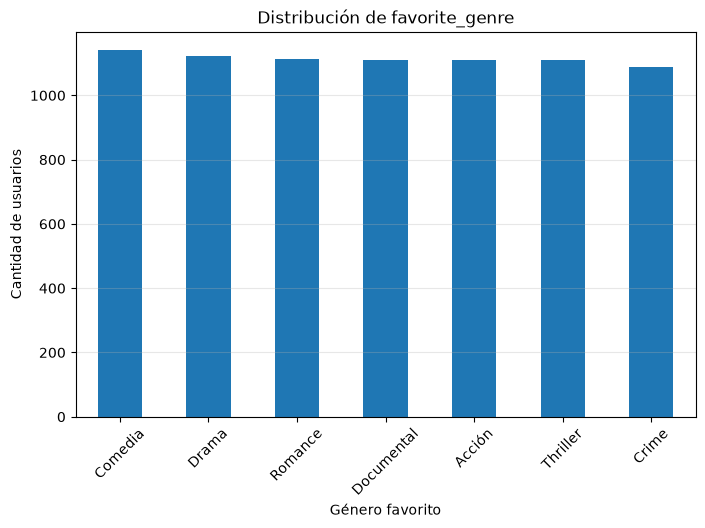

In [97]:
# GRÁFICO DE BARRAS DE favorite_genre

# Excluir los valores faltantes para visualizar únicamente las categorías existentes
generos = df_limpio["favorite_genre"].dropna()

plt.figure(figsize=(8,5))

generos.value_counts().plot(kind="bar")

plt.title("Distribución de favorite_genre")
plt.xlabel("Género favorito")
plt.ylabel("Cantidad de usuarios")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

El gráfico confirma el reparto equilibrado entre géneros.

### Géneros según el plan

In [98]:
# DISTRIBUCIÓN DE favorite_genre SEGÚN subscription_plan


tabla_generos_plan = pd.crosstab(
    df_limpio["subscription_plan"],
    df_limpio["favorite_genre"]
)

tabla_generos_plan

favorite_genre,Acción,Comedia,Crime,Documental,Drama,Romance,Thriller
subscription_plan,,,,,,,
Básico,495,534,478,482,511,513,483
Estándar,396,386,399,399,387,386,395
Premium,219,221,212,230,223,214,231


La distribución de géneros se mantiene pareja dentro de cada plan.

### Porcentajes por plan

In [99]:
# PORCENTAJES POR PLAN DE SUSCRIPCIÓN

tabla_generos_plan_pct = (
    pd.crosstab(
        df_limpio["subscription_plan"],
        df_limpio["favorite_genre"],
        normalize="index"
    ) * 100
).round(2)

tabla_generos_plan_pct

favorite_genre,Acción,Comedia,Crime,Documental,Drama,Romance,Thriller
subscription_plan,,,,,,,
Básico,14.16,15.27,13.67,13.79,14.62,14.67,13.82
Estándar,14.41,14.05,14.52,14.52,14.08,14.05,14.37
Premium,14.13,14.26,13.68,14.84,14.39,13.81,14.90


Las diferencias entre géneros son mínimas (menos de 1%), incluso mirando por plan.

### Imputación con 'Desconocido'

In [100]:
# IMPUTACIÓN DE favorite_genre
# MEDIANTE LA CATEGORÍA "Desconocido"


# Reemplazar los valores faltantes
df_limpio["favorite_genre"] = df_limpio["favorite_genre"].fillna("Desconocido")

# Verificar que no queden valores faltantes
print("Valores faltantes restantes:")
print(df_limpio["favorite_genre"].isna().sum())

print("\nDistribución actualizada:\n")
print(df_limpio["favorite_genre"].value_counts())

Valores faltantes restantes:
0

Distribución actualizada:

favorite_genre
Comedia        1141
Drama          1121
Romance        1113
Documental     1111
Acción         1110
Thriller       1109
Crime          1089
Desconocido     240
Name: count, dtype: int64


Como ningún género predomina, los faltantes se marcan como 'Desconocido' en vez de inventar una categoría. Quedan 0 faltantes.

## 8. Faltantes en `last_login_date`

Antes de decidir qué hacer con las fechas faltantes (NaT), vemos si se concentran en algún grupo.

### Faltantes según el plan

In [101]:
# DISTRIBUCIÓN DE NaT SEGÚN EL PLAN DE SUSCRIPCIÓN


tabla_nat_plan = pd.crosstab(
    df_limpio["subscription_plan"],
    df_limpio["last_login_date"].isna(),
    margins=True
)

# Renombrar únicamente las columnas booleanas
tabla_nat_plan = tabla_nat_plan.rename(
    columns={
        False: "Con fecha",
        True: "Sin fecha (NaT)"
    }
)

tabla_nat_plan

last_login_date,Con fecha,Sin fecha (NaT),All
subscription_plan,,,
Básico,3391,218,3609
Estándar,2664,169,2833
Premium,1493,99,1592
All,7548,486,8034


La proporción de fechas faltantes es similar en los tres planes.

### Faltantes según el país

In [102]:
# DISTRIBUCIÓN DE NaT SEGÚN EL PAÍS


tabla_nat_pais = pd.crosstab(
    df_limpio["country"],
    df_limpio["last_login_date"].isna()
)

# Renombrar columnas
tabla_nat_pais = tabla_nat_pais.rename(
    columns={
        False: "Con fecha",
        True: "Sin fecha (NaT)"
    }
)

# Calcular porcentaje de NaT por país
tabla_nat_pais["% NaT"] = (
    tabla_nat_pais["Sin fecha (NaT)"] /
    (tabla_nat_pais["Con fecha"] + tabla_nat_pais["Sin fecha (NaT)"])
    * 100
).round(2)

tabla_nat_pais.sort_values("% NaT", ascending=False)

last_login_date,Con fecha,Sin fecha (NaT),% NaT
country,,,
México,1080,82,7.06
Chile,1092,75,6.43
Brasil,1091,73,6.27
Uruguay,1076,70,6.11
Perú,1073,66,5.79
Argentina,1049,62,5.58
Colombia,1087,58,5.07


Tampoco hay un país que concentre las fechas faltantes; no se observa un patrón.

## 9. Tratamiento de `age`

En la inspección inicial se detectaron edades imposibles (mínimo -5, máximo 150). Las tratamos con el mismo criterio basado en evidencia.

### Edades imposibles

In [103]:
# Edades fuera de un rango humano plausible (0 < edad <= 100)
edades_invalidas = df_limpio[
    (df_limpio["age"] <= 0) | (df_limpio["age"] > 100)
]

print("Cantidad de edades inválidas:", len(edades_invalidas))
print("\nFrecuencia de los valores inválidos:")
print(
    edades_invalidas["age"].value_counts().sort_index()
)

Cantidad de edades inválidas: 98

Frecuencia de los valores inválidos:
age
-5      21
 0      24
 130    34
 150    19
Name: count, dtype: int64


Se detectan 98 edades imposibles: negativas, cero y los centinelas 130 y 150.

### Conversión a NaN

In [104]:
# Conversión de las edades inválidas a NaN
df_limpio["age"] = df_limpio["age"].where(
    (df_limpio["age"] > 0) & (df_limpio["age"] <= 100)
)

print("Valores faltantes en age tras la conversión:",
      df_limpio["age"].isna().sum())

Valores faltantes en age tras la conversión: 98


Las 98 edades imposibles pasan a faltantes.

### ¿La edad depende del plan?

In [105]:
# Evidencia para elegir la estrategia de imputación:
# ¿la edad difiere según el plan de suscripción?
df_limpio.groupby("subscription_plan")["age"].median()

subscription_plan
Básico      33.0
Estándar    34.0
Premium     33.0
Name: age, dtype: float64

La mediana de edad es casi igual en los tres planes (33/34/33): no hay diferencias por grupo.

### Imputación por mediana global

In [106]:
# Imputación por mediana global
mediana_edad = df_limpio["age"].median()

df_limpio["age"] = df_limpio["age"].fillna(mediana_edad)

print("Mediana global utilizada:", mediana_edad)
print("Valores faltantes restantes en age:", df_limpio["age"].isna().sum())

Mediana global utilizada: 33.0
Valores faltantes restantes en age: 0


Como la edad no difiere por plan, se imputa con la **mediana global (33)**. Es una decisión de bajo riesgo: la edad es casi simétrica (mediana ≈ media) y los inválidos son solo el **1,2%** del total, por lo que la media y el desvío prácticamente no cambian. Quedan 0 faltantes.

## 10. Tratamiento de `customer_support_tickets`

También presentaba valores imposibles (mínimo -1, máximo 150). Repetimos el criterio: detectar, convertir a NaN e imputar.

### Frecuencia de los valores

In [107]:
# Frecuencia completa de la variable
df_limpio["customer_support_tickets"].value_counts().sort_index()

customer_support_tickets
-1        29
 0      3574
 1      2831
 2      1167
 3       281
 4        71
 5        14
 99       35
 150      32
Name: count, dtype: int64

El rango válido es 0 a 5 consultas; -1 es imposible y 99/150 son saltos aislados (centinelas).

### Conversión de inválidos a NaN

In [108]:
# Conversión de los valores inválidos a NaN
df_limpio["customer_support_tickets"] = (
    df_limpio["customer_support_tickets"]
    .where(~df_limpio["customer_support_tickets"].isin([-1, 99, 150]))
)

print("Valores faltantes tras la conversión:",
      df_limpio["customer_support_tickets"].isna().sum())

Valores faltantes tras la conversión: 96


Los 96 valores inválidos (-1, 99 y 150) pasan a faltantes.

### ¿Los tickets dependen del plan?

In [109]:
# Evidencia para la imputación: ¿los tickets difieren según el plan?
df_limpio.groupby("subscription_plan")["customer_support_tickets"].median()

subscription_plan
Básico      1.0
Estándar    1.0
Premium     1.0
Name: customer_support_tickets, dtype: float64

La mediana de tickets es 1 en los tres planes: no hay diferencias por grupo.

### Imputación por mediana global

In [110]:
# Imputación por mediana global y restauración del tipo entero
mediana_tickets = df_limpio["customer_support_tickets"].median()

df_limpio["customer_support_tickets"] = (
    df_limpio["customer_support_tickets"]
    .fillna(mediana_tickets)
    .astype(int)
)

print("Mediana global utilizada:", mediana_tickets)
print("Valores faltantes restantes:",
      df_limpio["customer_support_tickets"].isna().sum())

Mediana global utilizada: 1.0
Valores faltantes restantes: 0


Se imputa con la **mediana global (1)** y se restaura el tipo entero. Los inválidos son solo el **1,2%** y, al tratarse de una cantidad de consultas, la mediana es la opción robusta; el impacto en la distribución es despreciable (la media se mantiene en ~0,80). Quedan 0 faltantes.

## 11. Registro de transformaciones y exportación

### Resumen de decisiones

**Con esta decisión queda finalizado el tratamiento de calidad, limpieza y valores faltantes del dataset.**

Resumen de las decisiones adoptadas

| Variable | Estrategia aplicada | Justificación |
| --- | --- | --- |
| `monthly_watch_time_mins` | Inválidos → NaN + imputación por **mediana según plan** | Existían diferencias claras entre planes y la mediana es robusta frente a valores extremos. |
| `favorite_genre` | Nueva categoría **"Desconocido"** | No existía una categoría predominante ni diferencias relevantes entre grupos. |
| `last_login_date` | **Conservar `NaT`** | No había evidencia suficiente para inferir fechas reales sin introducir información artificial. |
| `age` | Inválidos (≤0 y >100) → NaN + imputación por **mediana global** | Valores negativos/nulos y centinelas 130/150; la edad no difiere entre planes. |
| `customer_support_tickets` | Inválidos (-1, 99, 150) → NaN + imputación por **mediana global** | El rango válido es 0–5; -1 es imposible y 99/150 son centinelas; no difiere entre planes. |

### Registro del pipeline (log ETL)

In [113]:
# ==========================================================
# REGISTRO DE TRANSFORMACIONES DEL PIPELINE (LOG ETL)
# Columnas obligatorias: Paso | Descripción | Filas | Nulos | Retención (%)
# ==========================================================
import os

pipeline_log = pd.DataFrame([
    {"Paso": 0,  "Descripción": "Estado inicial (dataset crudo)",                                  "Filas": 8160, "Nulos": 753, "Retención (%)": 100.00},
    {"Paso": 1,  "Descripción": "Eliminación de registros duplicados completos",                   "Filas": 8034, "Nulos": 753, "Retención (%)": 98.46},
    {"Paso": 2,  "Descripción": "Estandarización de subscription_plan",                            "Filas": 8034, "Nulos": 753, "Retención (%)": 98.46},
    {"Paso": 3,  "Descripción": "Estandarización de country",                                      "Filas": 8034, "Nulos": 753, "Retención (%)": 98.46},
    {"Paso": 4,  "Descripción": "Estandarización de favorite_genre",                               "Filas": 8034, "Nulos": 753, "Retención (%)": 98.46},
    {"Paso": 5,  "Descripción": "Conversión de last_login_date a datetime",                        "Filas": 8034, "Nulos": 919, "Retención (%)": 98.46},
    {"Paso": 6,  "Descripción": "monthly_watch_time_mins: inválidos (-120,-1,50000,99999) a NaN",  "Filas": 8034, "Nulos": 999, "Retención (%)": 98.46},
    {"Paso": 7,  "Descripción": "monthly_watch_time_mins: imputación por mediana según plan",      "Filas": 8034, "Nulos": 726, "Retención (%)": 98.46},
    {"Paso": 8,  "Descripción": "favorite_genre: imputación con categoría 'Desconocido'",          "Filas": 8034, "Nulos": 486, "Retención (%)": 98.46},
    {"Paso": 9,  "Descripción": "last_login_date: conservación de valores NaT",                    "Filas": 8034, "Nulos": 486, "Retención (%)": 98.46},
    {"Paso": 10, "Descripción": "age: inválidos (<=0 y >100) a NaN",                               "Filas": 8034, "Nulos": 584, "Retención (%)": 98.46},
    {"Paso": 11, "Descripción": "age: imputación por mediana global",                              "Filas": 8034, "Nulos": 486, "Retención (%)": 98.46},
    {"Paso": 12, "Descripción": "customer_support_tickets: inválidos (-1,99,150) a NaN",           "Filas": 8034, "Nulos": 582, "Retención (%)": 98.46},
    {"Paso": 13, "Descripción": "customer_support_tickets: imputación por mediana global",         "Filas": 8034, "Nulos": 486, "Retención (%)": 98.46},
])

os.makedirs("../logs", exist_ok=True)
pipeline_log.to_csv("../logs/pipeline_log.csv", index=False, encoding="utf-8-sig")

print("Pipeline log generado correctamente.")
pipeline_log

Pipeline log generado correctamente.


,Paso,Descripción,Filas,Nulos,Retención (%)
0,0,Estado inicial (dataset crudo),8160,753,100.00
1,1,Eliminación de registros duplicados completos,8034,753,98.46
2,2,Estandarización de subscription_plan,8034,753,98.46
3,3,Estandarización de country,8034,753,98.46
4,4,Estandarización de favorite_genre,8034,753,98.46
5,5,Conversión de last_login_date a datetime,8034,919,98.46
6,6,"monthly_watch_time_mins: inválidos (-120,-1,50...",8034,999,98.46
7,7,monthly_watch_time_mins: imputación por median...,8034,726,98.46
8,8,favorite_genre: imputación con categoría 'Desc...,8034,486,98.46
9,9,last_login_date: conservación de valores NaT,8034,486,98.46


Cada transformación queda registrada en `logs/pipeline_log.csv` con las columnas obligatorias (Paso, Descripción, Filas, Nulos, Retención %). Permite comparar el estado inicial (8160 filas, 753 nulos) con el final (8034 filas, 486 nulos).

### Exportación del dataset procesado

In [114]:
# EXPORTAR EL DATASET PROCESADO
import os

# Crear la carpeta si no existe
os.makedirs("../data/processed", exist_ok=True)

# Guardar el dataset limpio
df_limpio.to_csv(
    "../data/processed/streaming_users_processed.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset procesado guardado correctamente.")

Dataset procesado guardado correctamente.


El dataset limpio se guarda en `data/processed/streaming_users_processed.csv`, listo para el análisis del próximo notebook.